<a href="https://colab.research.google.com/github/jiyapatel18/Jiya-Patel/blob/main/diabetes1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("/content/Sheet 1-1-diabetes.csv")

print(df.head())
print(df.shape)
print(df.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose             

In [ ]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, pd.NA)

df[cols] = df[cols].fillna(df[cols].median())

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


/tmp/ipykernel_706/2475235097.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols] = df[cols].fillna(df[cols].median())


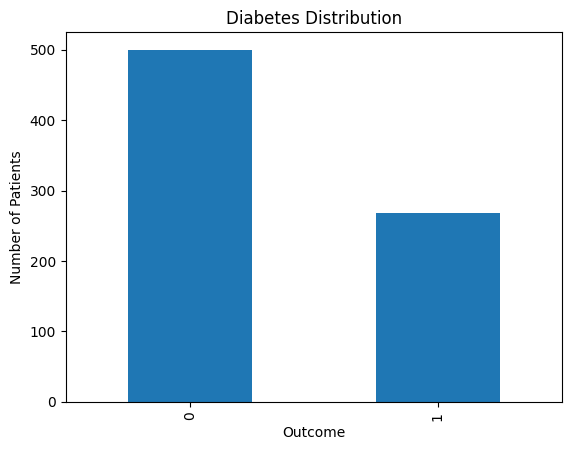

In [ ]:
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabetes Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.show()

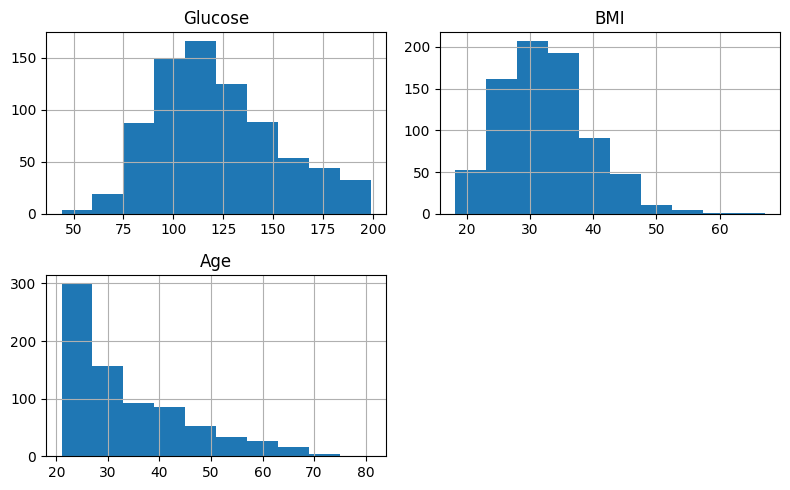

In [ ]:
df[['Glucose', 'BMI', 'Age']].hist(figsize=(8,5))
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

Outcome
0    400
1    400
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

print(classification_report(y_test, pred_lr))

Logistic Regression Accuracy: 0.7142857142857143
ROC-AUC: 0.8088888888888889
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154



In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

print(classification_report(y_test, pred_rf))

Random Forest Accuracy: 0.7467532467532467
ROC-AUC: 0.8130555555555555
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       100
           1       0.63      0.69      0.65        54

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



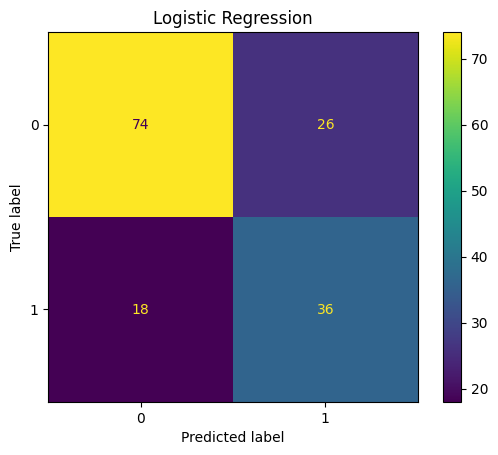

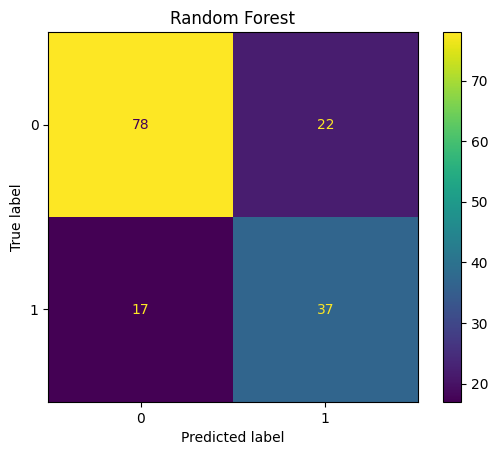

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression")
plt.show()

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

params_lr = {
    'C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(LogisticRegression(), params_lr, cv=5)

grid_lr.fit(X_train, y_train)

print("Best Logistic Regression Parameters:",
      grid_lr.best_params_)

Best Logistic Regression Parameters: {'C': 1}


In [ ]:
params_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params_rf,
    cv=5
)

grid_rf.fit(X_train, y_train)

print("Best Random Forest Parameters:",
      grid_rf.best_params_)

Best Random Forest Parameters: {'max_depth': None, 'n_estimators': 100}


In [ ]:
print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, grid_lr.predict_proba(X_test)[:,1]))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, grid_rf.predict_proba(X_test)[:,1]))

Logistic Regression ROC-AUC: 0.8088888888888889
Random Forest ROC-AUC: 0.8130555555555555


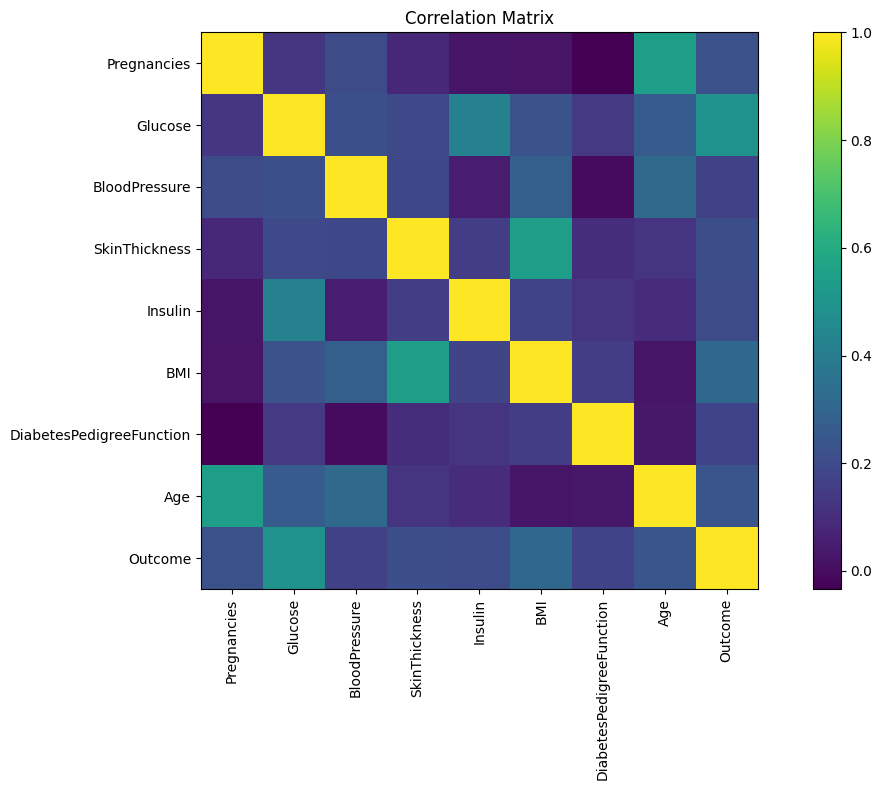

In [ ]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

plt.imshow(correlation, interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()